# Stage 1-1. Config and Task Specification

이 노트북은 Stage 1에서 구현한 두 모듈을 실습한다.

- `src/config.py` — 프로젝트 기본 설정값을 dict로 반환하는 `get_default_config()`
- `src/task.py` — 과제 규약을 정의하는 `get_task_spec()` 및 `transform_targets()`

**학습 목표**
1. `get_default_config()`가 반환하는 설정값의 구조를 확인한다.
2. 3종 task(`multiclass`, `binary`, `regression`)의 spec을 비교한다.
3. `transform_targets()`가 task별로 어떻게 target 배열을 변환하는지 시각화한다.

## 0. 환경 설정

In [1]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.config import get_default_config
from src.task import get_task_spec, transform_targets

## 1. 기본 설정 (Config)

`get_default_config()`는 프로젝트 전반에서 사용하는 기본값을 dict로 반환한다.  
각 키의 의미는 다음과 같다.

| 키 | 의미 |
|---|---|
| `dataset_dir` | MNIST 로컬 데이터셋 경로 |
| `seed` | 재현성을 위한 난수 시드 |
| `batch_size` | 미니배치 크기 |
| `num_epochs` | 학습 epoch 수 |
| `task` | 과제 유형 (`multiclass` / `binary` / `regression`) |
| `split` | 데이터 분할 (`train` / `test`) |

In [2]:
config = get_default_config()
print("Default config:")
for k, v in config.items():
    print(f"  {k}: {v!r}")

Default config:
  dataset_dir: '/mnt/d/datasets/mnist'
  seed: 42
  batch_size: 64
  num_epochs: 10
  task: 'multiclass'
  split: 'train'


`config`는 dict이므로 키를 직접 수정하여 실험 조건을 바꿀 수 있다.

In [3]:
# 설정 오버라이드 예시
config["task"] = "binary"
config["num_epochs"] = 5
print("Modified config:")
for k, v in config.items():
    print(f"  {k}: {v!r}")

Modified config:
  dataset_dir: '/mnt/d/datasets/mnist'
  seed: 42
  batch_size: 64
  num_epochs: 5
  task: 'binary'
  split: 'train'


## 2. Task Spec 비교

`get_task_spec(task)`는 task별 모델 출력 규약을 dict로 반환한다.

| 키 | 의미 |
|---|---|
| `task` | 과제 이름 |
| `output_dim` | 모델의 출력 노드 수 |
| `target_dtype` | target 배열의 dtype |
| `prediction_mode` | 예측 후처리 방식 |

In [4]:
# Task spec 비교 표 출력
tasks = ["multiclass", "binary", "regression"]
rows = [get_task_spec(t) for t in tasks]
df = pd.DataFrame(rows).set_index("task")
df

,output_dim,target_dtype,prediction_mode
task,,,
multiclass,10,float32,argmax
binary,1,float32,threshold
regression,1,float32,round_clip


> **핵심**: `output_dim`은 multiclass일 때만 10이고, binary/regression은 모두 1이다.  
> `prediction_mode`는 후처리 방식을 결정하며 `Predictor`가 참조한다.

## 3. Target 변환 (`transform_targets`)

동일한 레이블 배열이 task에 따라 어떻게 변환되는지 확인한다.

In [5]:
# 0~9 레이블 10개짜리 샘플 배열
labels = np.arange(10, dtype=np.uint8)
print("labels:", labels, "shape:", labels.shape)

labels: [0 1 2 3 4 5 6 7 8 9] shape: (10,)


In [6]:
# multiclass: one-hot encoding → shape (10, 10)
t_mc = transform_targets(labels, "multiclass")
print("multiclass targets shape:", t_mc.shape)
print(t_mc)

multiclass targets shape: (10, 10)
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


In [7]:
# binary: 홀수=1, 짝수=0 → shape (10, 1)
t_bin = transform_targets(labels, "binary")
print("binary targets shape:", t_bin.shape)
print(t_bin.T)  # 행으로 보기 쉽게

binary targets shape: (10, 1)
[[0. 1. 0. 1. 0. 1. 0. 1. 0. 1.]]


In [8]:
# regression: label / 9.0 → shape (10, 1)
t_reg = transform_targets(labels, "regression")
print("regression targets shape:", t_reg.shape)
print(t_reg.T)

regression targets shape: (10, 1)
[[0.         0.11111111 0.22222222 0.33333334 0.44444445 0.5555556
  0.6666667  0.7777778  0.8888889  1.        ]]


## 4. Target 분포 시각화

실제 MNIST 레이블(0~9 균등분포 가정)에 대해 각 task의 target 값 분포를 bar 차트로 비교한다.

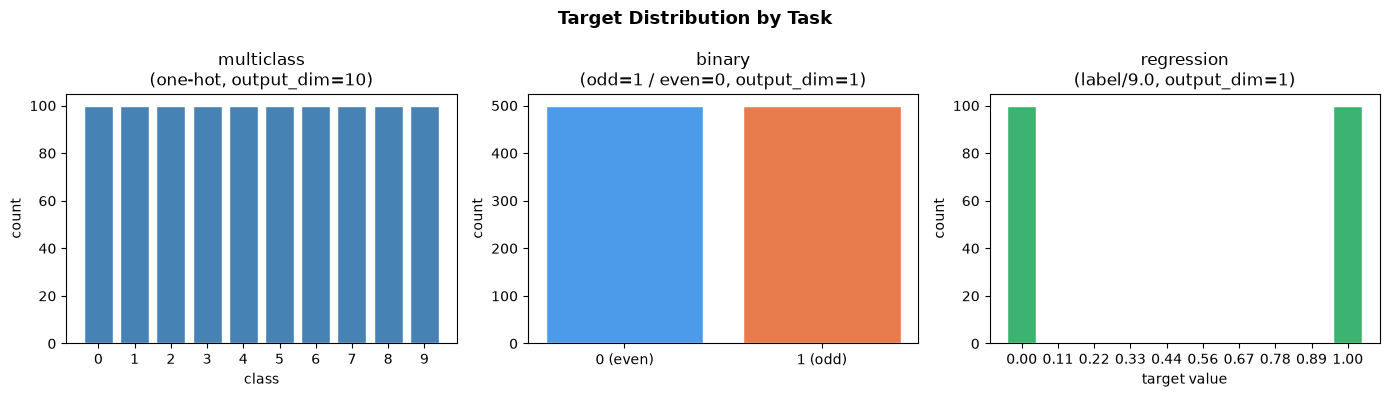

In [9]:
# 0~9 레이블 1000개 생성 (각 100개)
rng = np.random.default_rng(42)
demo_labels = np.repeat(np.arange(10, dtype=np.uint8), 100)
rng.shuffle(demo_labels)

t_mc  = transform_targets(demo_labels, "multiclass")
t_bin = transform_targets(demo_labels, "binary")
t_reg = transform_targets(demo_labels, "regression")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Target Distribution by Task", fontsize=13, fontweight="bold")

# multiclass: 클래스별 샘플 수
class_counts = t_mc.sum(axis=0)
axes[0].bar(range(10), class_counts, color="steelblue", edgecolor="white")
axes[0].set_title("multiclass\n(one-hot, output_dim=10)")
axes[0].set_xlabel("class")
axes[0].set_ylabel("count")
axes[0].set_xticks(range(10))

# binary: 0/1 분포
binary_counts = [np.sum(t_bin == 0), np.sum(t_bin == 1)]
axes[1].bar(["0 (even)", "1 (odd)"], binary_counts, color=["#4C9BE8", "#E87B4C"], edgecolor="white")
axes[1].set_title("binary\n(odd=1 / even=0, output_dim=1)")
axes[1].set_ylabel("count")

# regression: target 값 분포
unique_vals = np.unique(np.round(t_reg, 4))
counts = [np.sum(np.isclose(t_reg, v)) for v in unique_vals]
axes[2].bar([f"{v:.2f}" for v in unique_vals], counts, color="mediumseagreen", edgecolor="white")
axes[2].set_title("regression\n(label/9.0, output_dim=1)")
axes[2].set_xlabel("target value")
axes[2].set_ylabel("count")

plt.tight_layout()
plt.show()

## 5. 정리

| 항목 | multiclass | binary | regression |
|---|---|---|---|
| target 변환 | one-hot (N, 10) | 홀수=1 / 짝수=0, (N, 1) | label/9.0, (N, 1) |
| output_dim | 10 | 1 | 1 |
| prediction_mode | argmax | threshold (≥0.5) | round_clip |

**핵심 설계 원칙**
- `get_default_config()`는 dict를 반환하므로 키 오버라이드만으로 실험 조건을 변경할 수 있다.
- `get_task_spec(task)`는 모델 구성(output_dim)과 후처리(prediction_mode)에 필요한 정보를 한 곳에서 제공한다.
- `transform_targets(labels, task)`는 `MnistDataset` 내부에서 호출되므로 클라이언트 코드가 직접 호출할 일은 없다.